<a href="https://colab.research.google.com/github/ashnagibbons/MAT328Midterm/blob/main/MAT328MidtermProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

See the full analysis and discussion on the website: https://sites.google.com/view/agmat328oregonproperties/home

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Two ways to download the CSV file (method two at the end of the notebook)**

1. From Kaggle

- Go to https://www.kaggle.com/datasets/kanchana1990/real-estate-data-oregon-2026 and download the main csv file. Save it to your comptuer

- Run the cell below. When the button saying choose files comes up, select the file you just downloaded from your computer

In [7]:
from google.colab import files
uploaded = files.upload()

Saving oregon_real_estate_2026_ultimate.csv to oregon_real_estate_2026_ultimate (1).csv


- Run this cell to load the file into a pandas dataframe

In [9]:
import io
df = pd.read_csv(io.BytesIO(uploaded['oregon_real_estate_2026_ultimate (1).csv']))

In [10]:
df

,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built
0,single_family,NaN,Showings subject to accepted offer. Investor o...,179950.0,698.0,1.0,2.0,1.0,1.0,1.0,NaN,1897.0
1,single_family,NaN,*DO NOT DRIVE BY WITHOUT AN APPOINTMENT* Distr...,399900.0,2736.0,2.0,4.0,2.0,2.0,2.0,2.0,1990.0
2,condos,condo,This exceptional property is priced to sell & ...,220000.0,1130.0,1.0,3.0,3.0,3.0,3.0,NaN,2011.0
3,single_family,NaN,Commercially zoned property currently utilized...,230000.0,1293.0,2.0,3.0,2.0,2.0,2.0,1.0,1956.0
4,condos,condo,Sophisticated and beautifully updated riverfro...,899000.0,3172.0,3.0,3.0,4.0,4.0,4.0,1.0,2006.0
...,...,...,...,...,...,...,...,...,...,...,...,...
10398,townhomes,townhouse,"New Construction, Brynhill Community, Daphne F...",329900.0,1441.0,2.0,3.0,2.0,2.0,2.0,2.0,2026.0
10399,single_family,NaN,Light and bright bungalow on .25 acre lot. (Zo...,415000.0,1238.0,2.0,2.0,1.0,1.0,1.0,1.0,1953.0
10400,single_family,NaN,This is one of the very best floating home loc...,750000.0,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN
10401,townhomes,townhouse,Live new without the new-construction wait in ...,387500.0,1332.0,2.0,2.0,2.0,2.0,2.0,1.0,2025.0


In [11]:
df['sub_type'].value_counts()

,count
sub_type,
condo,859
townhouse,486


In [12]:
df.isna().sum()

,0
type,0
sub_type,9058
text,19
listPrice,0
sqft,2076
stories,2214
beds,2069
baths,2002
baths_full,2092
baths_full_calc,2090


In [13]:
no_land = df[df['type'] != 'land']
no_land.isna().sum()
#len(no_land)

,0
type,0
sub_type,7186
text,15
listPrice,0
sqft,204
stories,342
beds,197
baths,321
baths_full,220
baths_full_calc,218


In [14]:
new_df = no_land.drop(columns=['sub_type'])

In [15]:
print(len(new_df))
new_df.isna().sum()

8531


,0
type,0
text,15
listPrice,0
sqft,204
stories,342
beds,197
baths,321
baths_full,220
baths_full_calc,218
garage,1914


In [16]:
new_df = new_df.dropna()
len(new_df)

6200

In [17]:
new_df.isna().sum()

,0
type,0
text,0
listPrice,0
sqft,0
stories,0
beds,0
baths,0
baths_full,0
baths_full_calc,0
garage,0


In [18]:
new_df['type'].value_counts()

,count
type,
single_family,5174
condos,510
townhomes,409
multi_family,77
farm,30


In [19]:
new_df.columns

Index(['type', 'text', 'listPrice', 'sqft', 'stories', 'beds', 'baths',
       'baths_full', 'baths_full_calc', 'garage', 'year_built'],
      dtype='object')

Text(0, 0.5, 'Number of Properties')

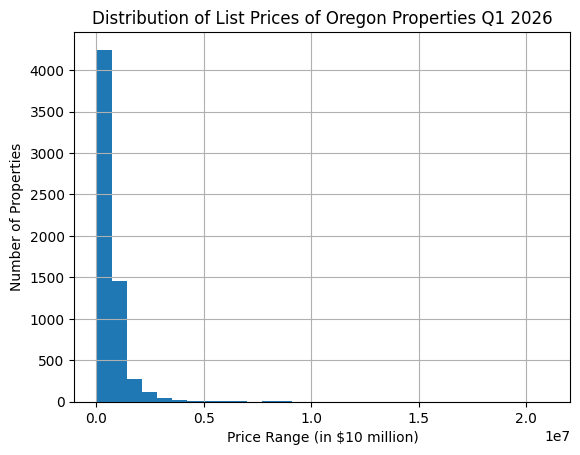

In [20]:
new_df['listPrice'].hist(bins=30)
plt.title('Distribution of List Prices of Oregon Properties Q1 2026')
plt.xlabel('Price Range (in $10 million)')
plt.ylabel('Number of Properties')

In [21]:
new_df['listPrice'].mean()

np.float64(763894.9879032258)

In [22]:
new_df['listPrice'].median()

575000.0

In [23]:
land = df[df['type'] == 'land']
print(len(land))
land.isna().sum()

1872


,0
type,0
sub_type,1872
text,4
listPrice,0
sqft,1872
stories,1872
beds,1872
baths,1681
baths_full,1872
baths_full_calc,1872


In [24]:
land.columns

Index(['type', 'sub_type', 'text', 'listPrice', 'sqft', 'stories', 'beds',
       'baths', 'baths_full', 'baths_full_calc', 'garage', 'year_built'],
      dtype='object')

In [25]:
land = land.drop(columns=['sub_type', 'sqft', 'stories', 'beds', 'baths', 'baths_full', 'baths_full_calc', 'garage', 'year_built'])

Text(0, 0.5, 'Number of Properties')

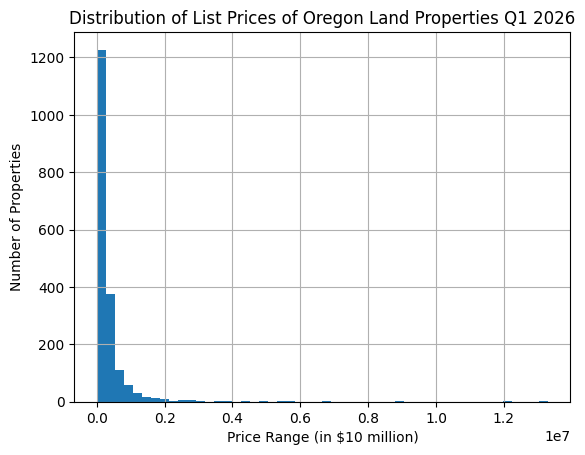

In [26]:
land['listPrice'].hist(bins=50)
plt.title('Distribution of List Prices of Oregon Land Properties Q1 2026')
plt.xlabel('Price Range (in $10 million)')
plt.ylabel('Number of Properties')

In [27]:
land['listPrice'].mean()

np.float64(348320.69177350425)

In [28]:
land['listPrice'].median()

183500.0

Text(0, 0.5, 'Number of Properties')

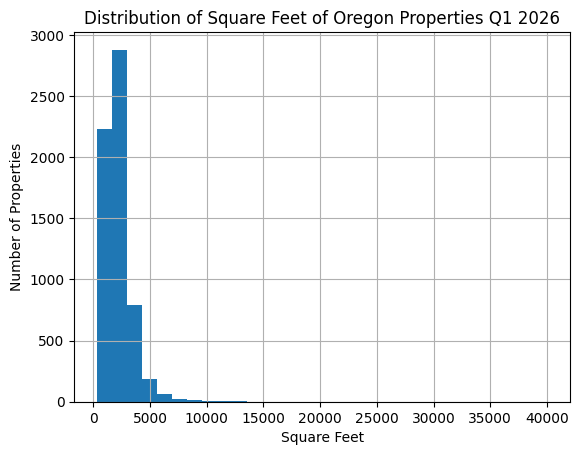

In [29]:
new_df['sqft'].hist(bins=30)
plt.title('Distribution of Square Feet of Oregon Properties Q1 2026')
plt.xlabel('Square Feet')
plt.ylabel('Number of Properties')

In [30]:
print(new_df['sqft'].mean())
print(new_df['sqft'].median())
print(new_df['sqft'].max())

2211.075806451613
1912.5
40075.0


Text(0, 0.5, 'Number of Properties')

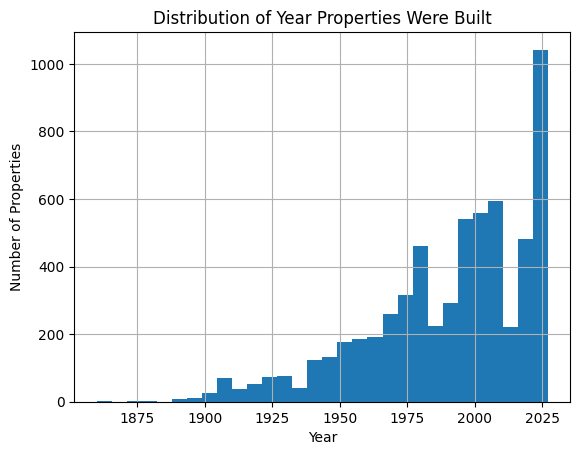

In [31]:
new_df['year_built'].hist(bins=30)
plt.title('Distribution of Year Properties Were Built')
plt.xlabel('Year')
plt.ylabel('Number of Properties')

Text(0, 0.5, 'Frequency')

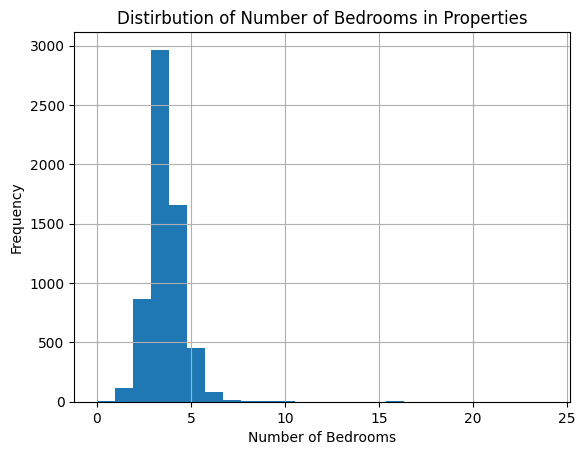

In [32]:
new_df['beds'].hist(bins=25)
plt.title('Distirbution of Number of Bedrooms in Properties')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Frequency')

In [33]:
new_df['beds'].max()

24.0

Text(9.444444444444445, 0.5, 'List Price (in $10 Million)')

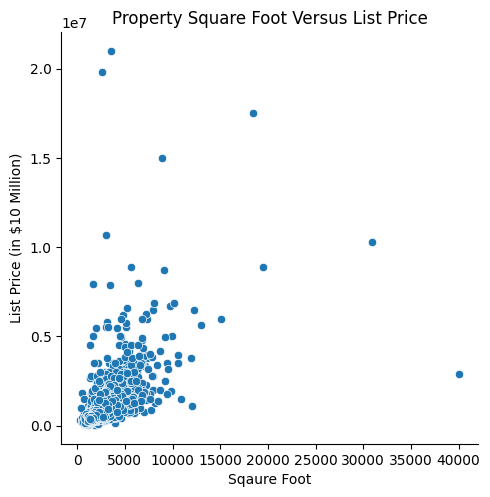

In [34]:
sns.relplot(x='sqft', y='listPrice', data=new_df)
plt.title('Property Square Foot Versus List Price')
plt.xlabel('Sqaure Foot')
plt.ylabel('List Price (in $10 Million)')

Text(0, 0.5, 'List Price (in $10 Million)')

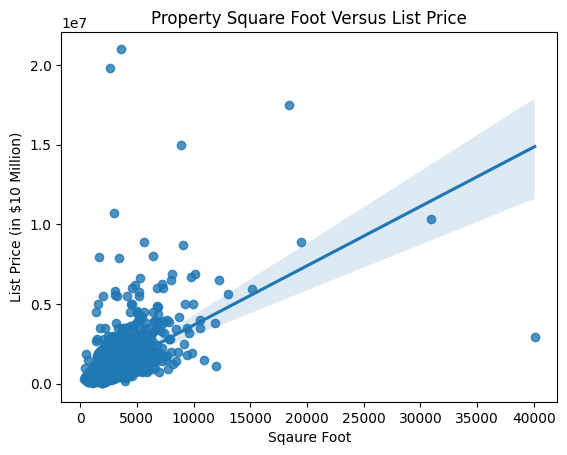

In [35]:
sns.regplot(x='sqft', y='listPrice', data=new_df)
plt.title('Property Square Foot Versus List Price')
plt.xlabel('Sqaure Foot')
plt.ylabel('List Price (in $10 Million)')

Text(9.444444444444445, 0.5, 'List Price (in $10 Million)')

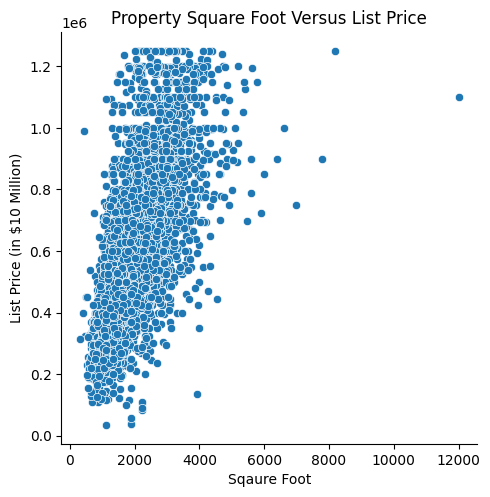

In [36]:
price_filter = new_df['listPrice'] <= 1250000
sqft_filter = new_df['sqft'] <= 20000
zoomed_df = new_df[price_filter & sqft_filter]

sns.relplot(x='sqft', y='listPrice', data=zoomed_df)
plt.title('Property Square Foot Versus List Price')
plt.xlabel('Sqaure Foot')
plt.ylabel('List Price (in $10 Million)')

Text(0, 0.5, 'List Price (in $1 Million)')

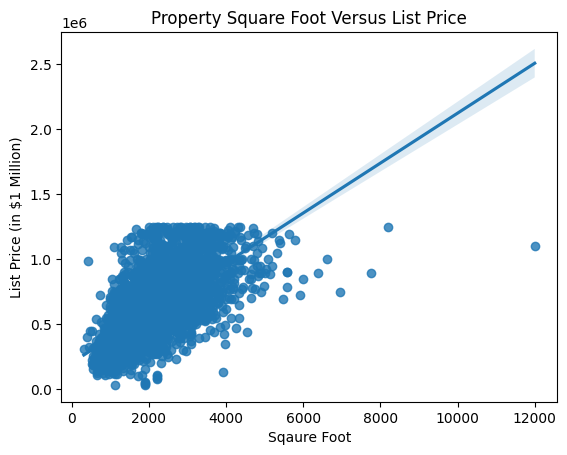

In [37]:
sns.regplot(x='sqft', y='listPrice', data=zoomed_df)
plt.title('Property Square Foot Versus List Price')
plt.xlabel('Sqaure Foot')
plt.ylabel('List Price (in $1 Million)')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
 [Text(0, 0, '0.0'),
  Text(1, 0, '1.0'),
  Text(2, 0, '2.0'),
  Text(3, 0, '3.0'),
  Text(4, 0, '4.0'),
  Text(5, 0, '5.0'),
  Text(6, 0, '6.0'),
  Text(7, 0, '7.0'),
  Text(8, 0, '8.0'),
  Text(9, 0, '9.0'),
  Text(10, 0, '10.0'),
  Text(11, 0, '11.0'),
  Text(12, 0, '12.0'),
  Text(13, 0, '13.0'),
  Text(14, 0, '16.0'),
  Text(15, 0, '17.0'),
  Text(16, 0, '24.0')])

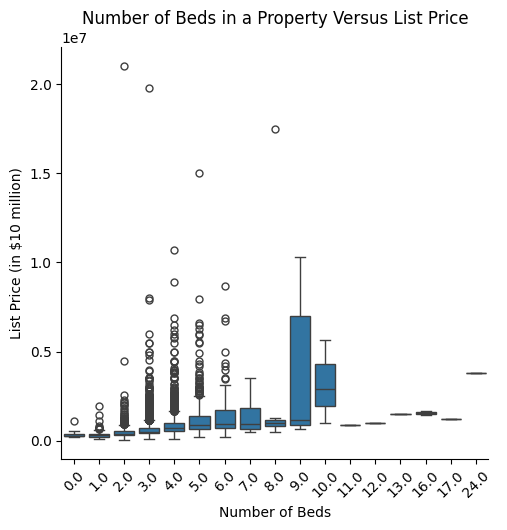

In [38]:
sns.catplot(x='beds', y='listPrice', kind='box', data=new_df)
plt.title('Number of Beds in a Property Versus List Price')
plt.xlabel('Number of Beds')
plt.ylabel('List Price (in $10 million)')
plt.xticks(rotation=45)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, '0.0'),
  Text(1, 0, '1.0'),
  Text(2, 0, '2.0'),
  Text(3, 0, '3.0'),
  Text(4, 0, '4.0'),
  Text(5, 0, '5.0'),
  Text(6, 0, '6.0'),
  Text(7, 0, '7.0'),
  Text(8, 0, '8.0'),
  Text(9, 0, '9.0'),
  Text(10, 0, '10.0')])

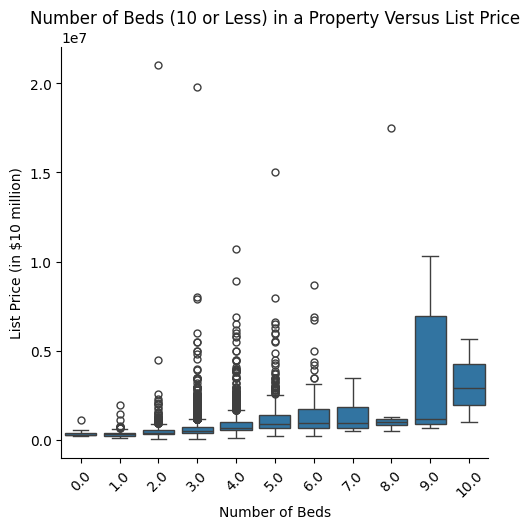

In [39]:
low_beds_df = new_df[new_df['beds'] < 11]

sns.catplot(x='beds', y='listPrice', kind='box', data=low_beds_df)
plt.title('Number of Beds (10 or Less) in a Property Versus List Price')
plt.xlabel('Number of Beds')
plt.ylabel('List Price (in $10 million)')
plt.xticks(rotation=45)

2. From my GitHub

- Go to https://github.com/ashnagibbons/MAT328Midterm/blob/main/oregon_real_estate_2026_ultimate.csv and press the button that says Raw in the top right of the file

- Copy the url of the new page it takes you to and paste it in the variable called url in the cell below. Then run the cell

(Note: I am having trouble getting a static raw file on GitHub so if you don't go to my GitHub page and get the raw url yourself, it will give you a 404 error)

In [ ]:
url = 'your url'

df2 = pd.read_csv(url)

# **Milestone 2**

The first model to try is a decision tree.

In [40]:
import graphviz

from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import export_graphviz

from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import LinearRegression

%matplotlib inline

In [41]:
new_df.columns

Index(['type', 'text', 'listPrice', 'sqft', 'stories', 'beds', 'baths',
       'baths_full', 'baths_full_calc', 'garage', 'year_built'],
      dtype='object')

In [42]:
new_df = pd.get_dummies(new_df, columns=['type'], drop_first=True)

In [43]:
x = new_df.drop(columns=['text', 'listPrice'])

In [44]:
y = new_df['listPrice']

In [45]:
x.columns

Index(['sqft', 'stories', 'beds', 'baths', 'baths_full', 'baths_full_calc',
       'garage', 'year_built', 'type_farm', 'type_multi_family',
       'type_single_family', 'type_townhomes'],
      dtype='object')

In [46]:
y

,listPrice
1,399900.0
3,230000.0
4,899000.0
5,475000.0
6,379900.0
...,...
10396,349900.0
10398,329900.0
10399,415000.0
10401,387500.0


In [47]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [48]:
model_dep5 = DecisionTreeRegressor(max_depth=5)
model_dep5.fit(x_train,y_train)

DecisionTreeRegressor(max_depth=5)

In [49]:
from sklearn.tree import plot_tree

In [50]:
import matplotlib.pyplot as plt

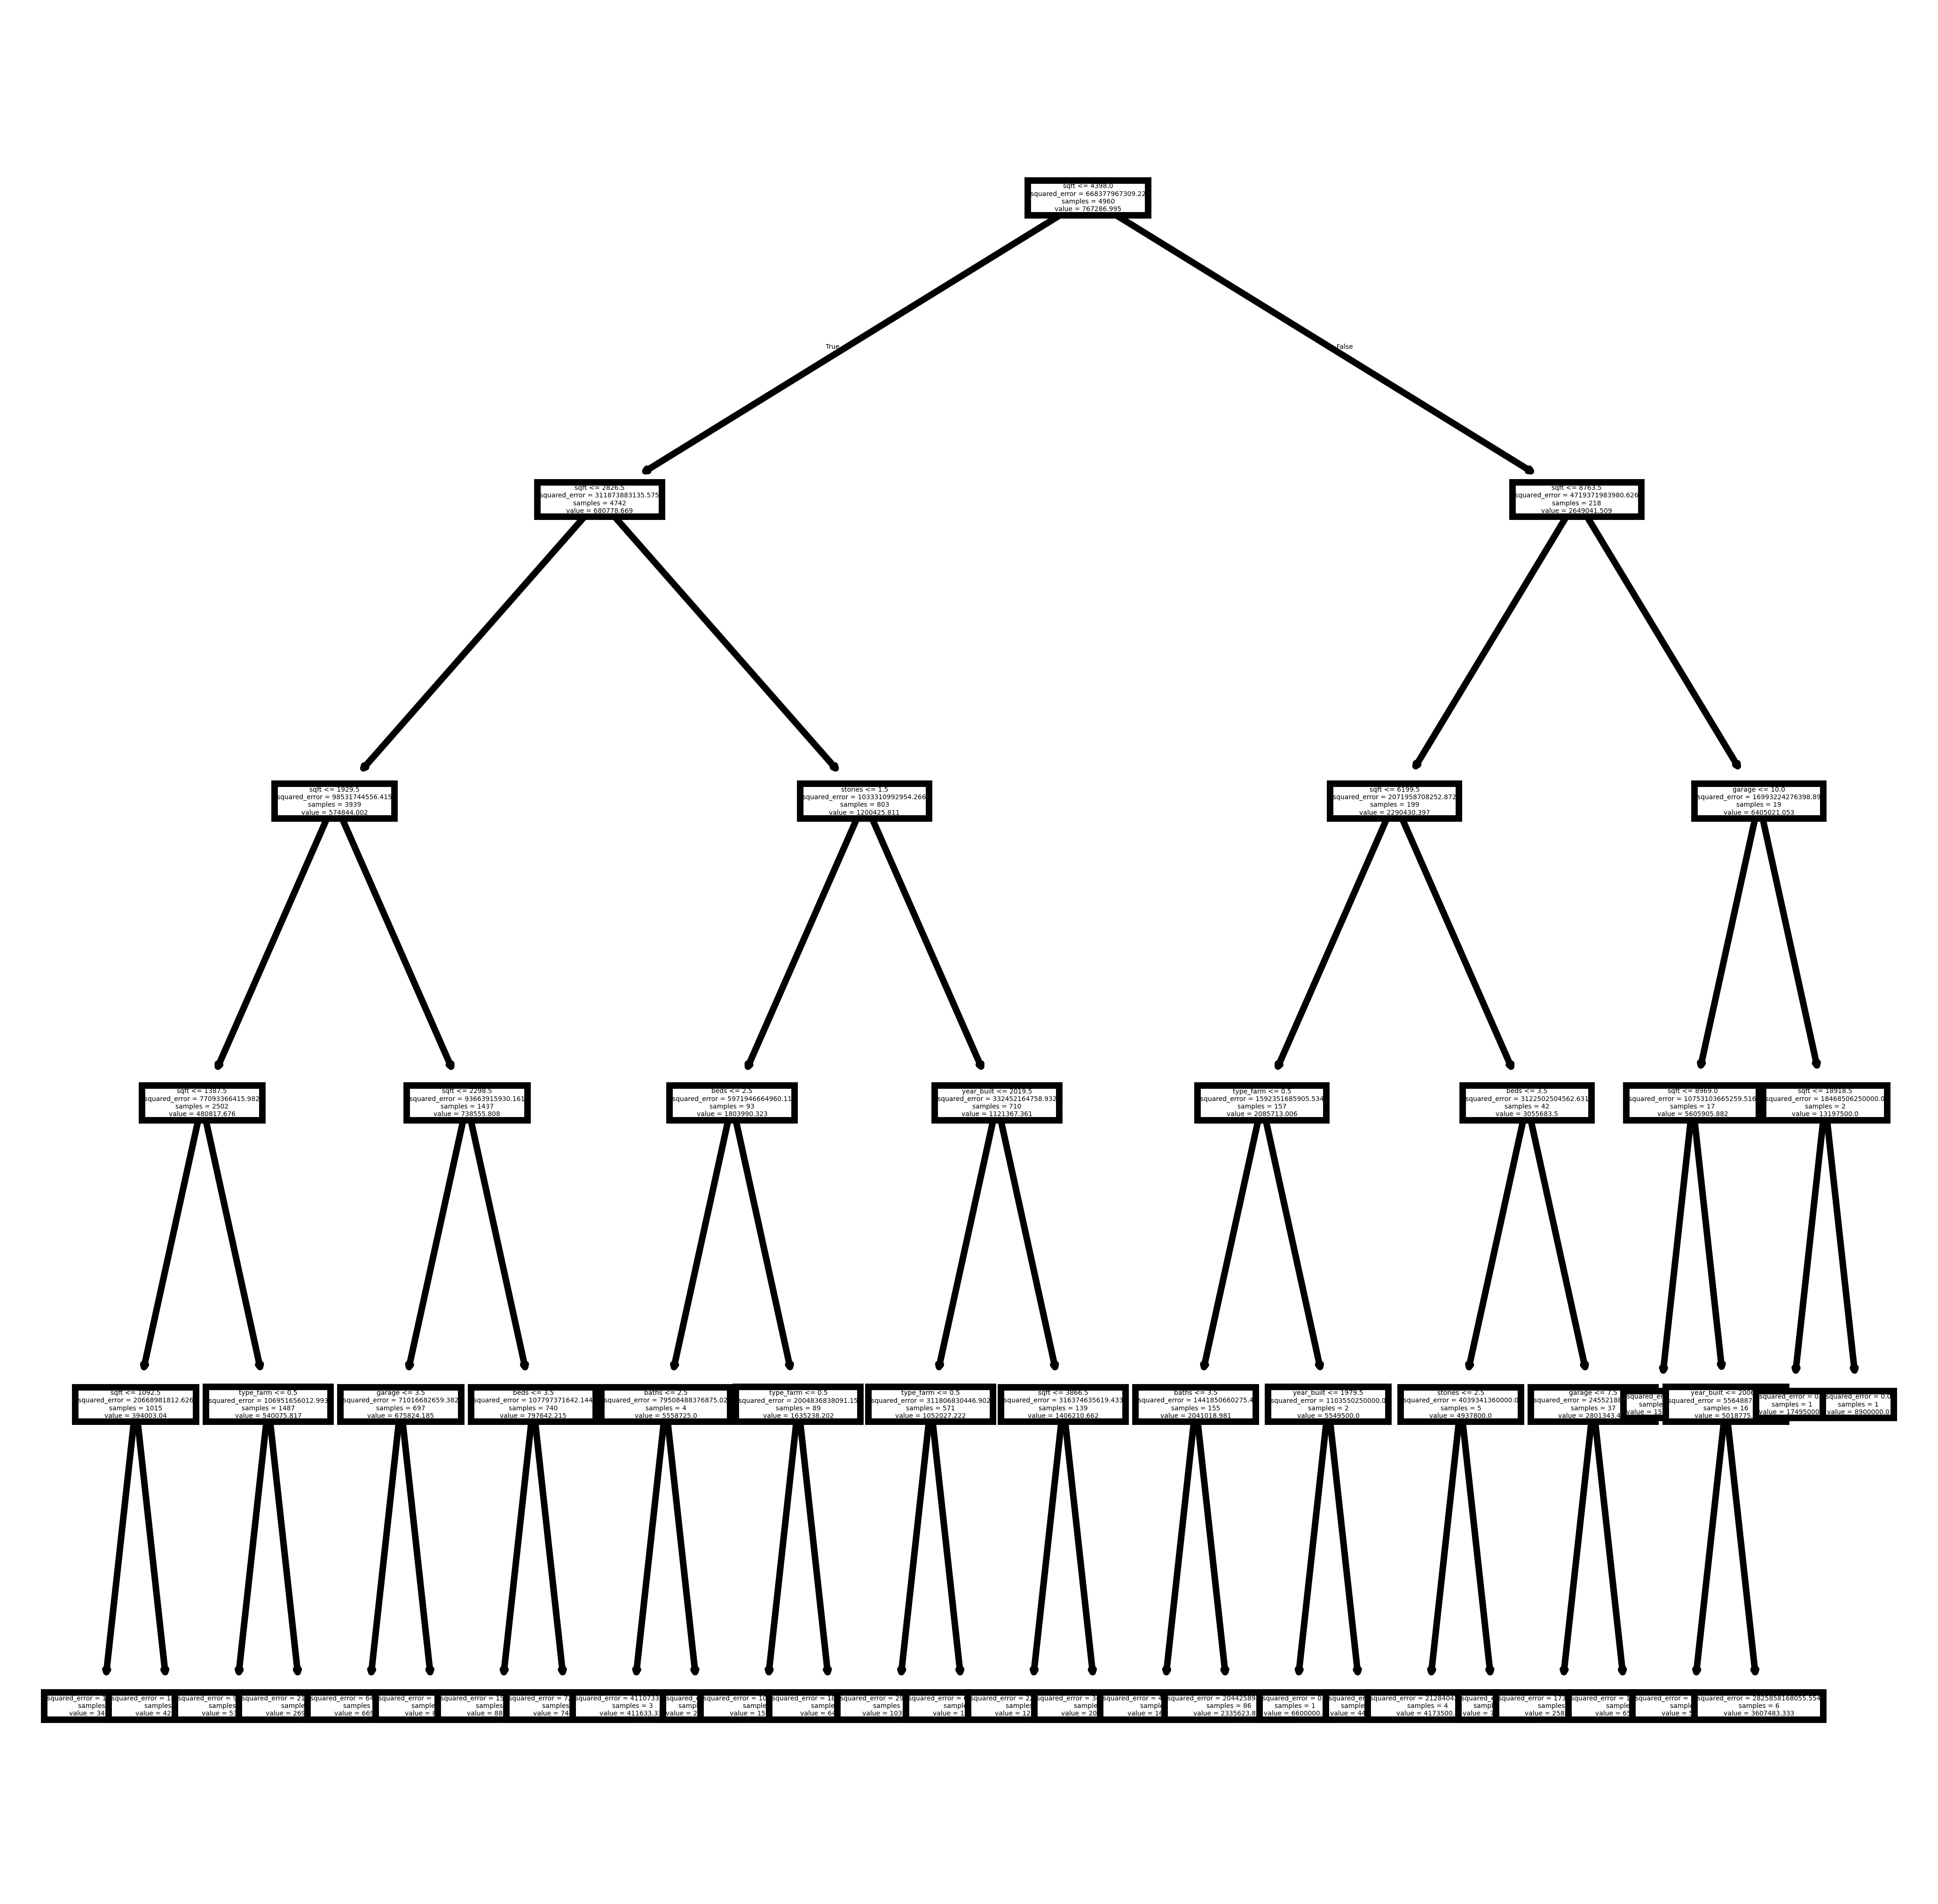

In [51]:
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (5,5), dpi=1000)
_ = plot_tree(model_dep5, feature_names=x.columns)

In [52]:
pred5 = model_dep5.predict(x_test)

In [53]:
mse5 = mean_squared_error(y_test, pred5)

In [54]:
mse5

490019013340.0071

In [55]:
predtrain5 = model_dep5.predict(x_train)

In [56]:
msetrain5 = mean_squared_error(y_train, predtrain5)

In [57]:
msetrain5

196067054289.02756

In [58]:
print(mse5 - msetrain5)

293951959050.9795


In [59]:
model_dep3 = DecisionTreeRegressor(max_depth=3)
model_dep3.fit(x_train,y_train)
pred3 = model_dep3.predict(x_test)
mse3 = mean_squared_error(y_test, pred3)
predtrain3 = model_dep3.predict(x_train)
msetrain3 = mean_squared_error(y_train, predtrain3)
print(mse3 - msetrain3)

184876019586.328


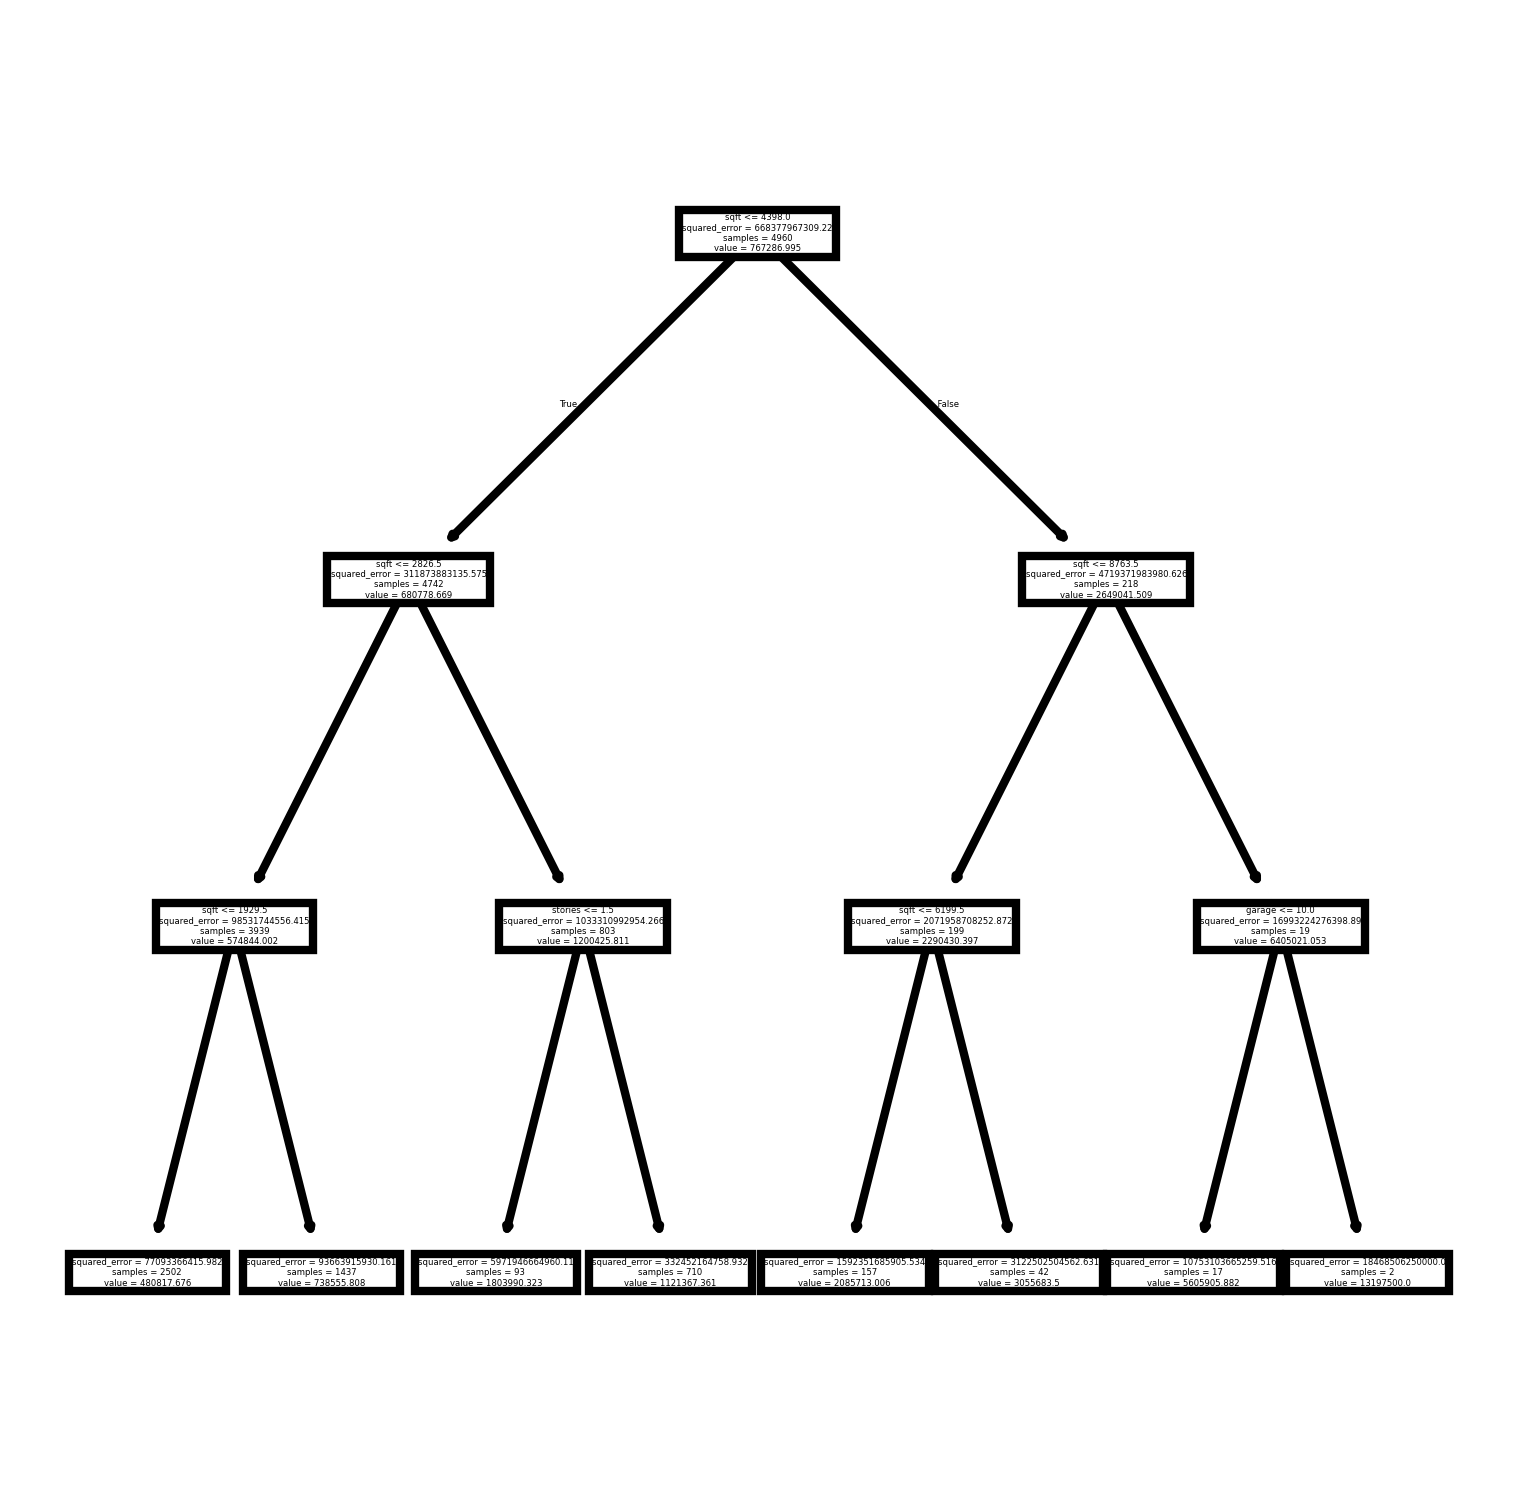

In [60]:
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (3,3), dpi=600)
_ = plot_tree(model_dep3, feature_names=x.columns)

In [61]:
model_dep7 = DecisionTreeRegressor(max_depth=7)
model_dep7.fit(x_train,y_train)
pred7 = model_dep7.predict(x_test)
mse7 = mean_squared_error(y_test, pred7)
predtrain7 = model_dep7.predict(x_train)
msetrain7 = mean_squared_error(y_train, predtrain7)
print(mse7 - msetrain7)

386211212538.8865


In [62]:
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (7,7), dpi=1400)
_ = plot_tree(model_dep7, feature_names=x.columns)

In [63]:
depths = [3, 5, 7]
mses = [mse3, mse5, mse7]
msetrains = [msetrain3, msetrain5, msetrain7]
mse_diffs = [mse3 - msetrain3, mse5 - msetrain5, mse7 - msetrain7]

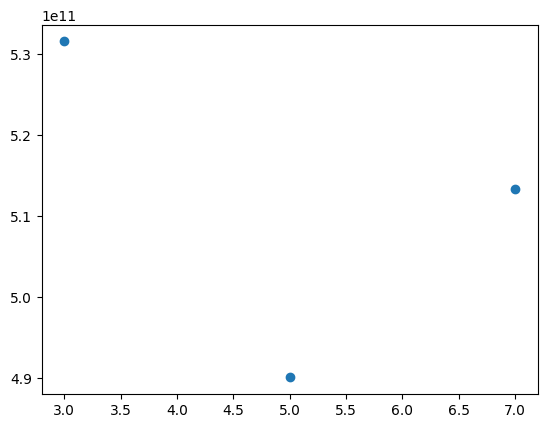

In [64]:
plt.scatter(depths, mses)

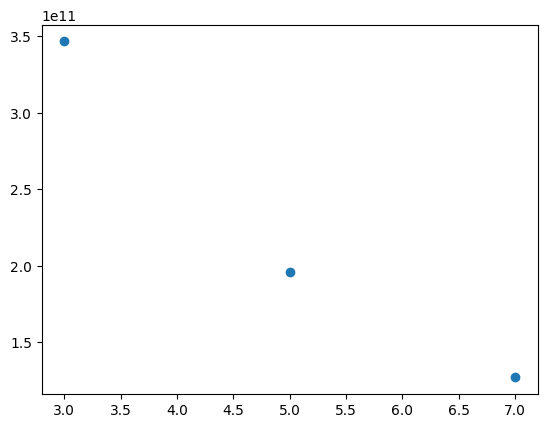

In [65]:
plt.scatter(depths, msetrains)

Text(0, 0.5, 'MSE on test - MSE on training')

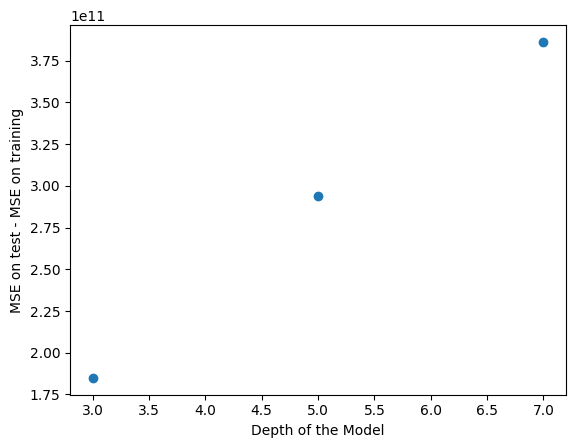

In [108]:
plt.scatter(depths, mse_diffs)
plt.xlabel('Depth of the Model')
plt.ylabel('MSE on test - MSE on training')

The second model is a linear regression.

In [67]:
import statsmodels.formula.api as smf

In [68]:
new_df.columns

Index(['text', 'listPrice', 'sqft', 'stories', 'beds', 'baths', 'baths_full',
       'baths_full_calc', 'garage', 'year_built', 'type_farm',
       'type_multi_family', 'type_single_family', 'type_townhomes'],
      dtype='object')

In [69]:
type(x_train)

pandas.core.frame.DataFrame

In [70]:
train_df = x_train

In [71]:
train_df['listPrice'] = y_train

In [72]:
test_df = x_test

In [73]:
test_df['listPrice'] = y_test

In [74]:
lm = smf.ols("listPrice ~ sqft + stories + beds + baths + baths_full + baths_full_calc + garage + year_built + type_farm + type_multi_family + type_single_family + type_townhomes", data = train_df).fit()

In [75]:
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              listPrice   R-squared:                       0.444
Model:                            OLS   Adj. R-squared:                  0.442
Method:                 Least Squares   F-statistic:                     328.9
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:00:57   Log-Likelihood:                -73109.
No. Observations:                4960   AIC:                         1.462e+05
Df Residuals:                    4947   BIC:                         1.463e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                   -4.61e+05   6.12e+05     -0.753      0.451   -1.66e+06    7.39e+05
type_farm[T.True]           1.429e+06   1.27e+05     11.259      0.000    1.18e+06    1.68e+06
type_multi_family[T.True]  -5.536e+05    9.6e+04     -5.766      0.000   -7.42e+05   -3.65e+05
type_single_family[T.True]  2.079e+04    3.5e+04      0.594      0.553   -4.79e+04    8.95e+04
type_townhomes[T.True]     -2.942e+04   4.68e+04     -0.628      0.530   -1.21e+05    6.24e+04
sqft                         364.9626      8.769     41.620      0.000     347.772     382.154
stories                    -7.845e+04   1.46e+04     -5.382      0.000   -1.07e+05   -4.99e+04
beds                       -9.414e+04   1.22e+04     -7.687      0.000   -1.18e+05   -7.01e+04
baths                       1.336e+05   2.52e+04      5.297      0.000    8.41e+04    1.83e+05
baths_full                 -8.765e+05   2.74e+05     -3.204      0.001   -1.41e+06    -3.4e+05
baths_full_calc             8.908e+05   2.75e+05      3.238      0.001    3.51e+05    1.43e+06
garage                       118.6142    727.315      0.163      0.870   -1307.245    1544.474
year_built                   253.4619    307.561      0.824      0.410    -349.493     856.417
==============================================================================
Omnibus:                     8102.442   Durbin-Watson:                   2.044
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         17961771.320
Skew:                          10.237   Prob(JB):                         0.00
Kurtosis:                     297.096   Cond. No.                     2.23e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.23e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

This produces a very long equation, but we see multiple variables with p-values greater than 0.05: type_single_family, type_townhomes,  garage, and year_built. R-squared is .444.

<Axes: >

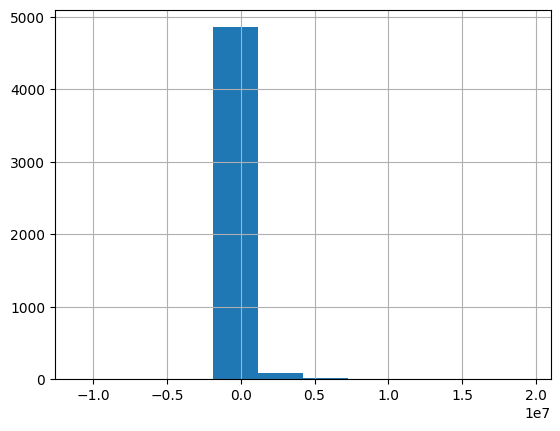

In [76]:
lm.resid.hist()

Text(0, 0.5, 'Residuals')

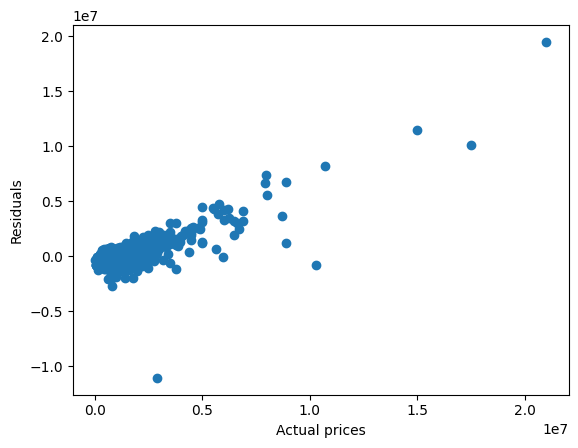

In [77]:
plt.scatter(x = train_df['listPrice'], y=lm.resid)
plt.xlabel("Actual prices")
plt.ylabel("Residuals")

In [81]:
pred = -4.61e+05 + test_df['type_farm']*1.429e+06 + test_df['type_multi_family']*-5.536e+05 + test_df['type_single_family']*2.079e+04 + test_df['type_townhomes']*-2.942e+04 + test_df['sqft']*	364.9626 +  test_df['stories']*-7.845e+04 + test_df['beds']*-9.414e+04 + test_df['baths']*1.336e+05 + test_df['baths_full']*-8.765e+05	+  test_df['baths_full_calc']*8.908e+05 + test_df['garage']*118.6142 + test_df['year_built']*253.4619

In [82]:
testmse = mean_squared_error(test_df['listPrice'], pred)
testmse

466784145537.9035

In [90]:
trainpred = -4.61e+05 + train_df['type_farm']*1.429e+06 + train_df['type_multi_family']*-5.536e+05 + train_df['type_single_family']*2.079e+04 + train_df['type_townhomes']*-2.942e+04 + train_df['sqft']*	364.9626 +  train_df['stories']*-7.845e+04 + train_df['beds']*-9.414e+04 + train_df['baths']*1.336e+05 + train_df['baths_full']*-8.765e+05	+  train_df['baths_full_calc']*8.908e+05 + train_df['garage']*118.6142 + train_df['year_built']*253.4619

In [91]:
trainmse = mean_squared_error(train_df['listPrice'], trainpred)
trainmse

371792714994.6681

In [92]:
print(testmse - trainmse)

94991430543.23541


We will try a new linear regression model without the variables that had high p-values.

In [86]:
lm2 = smf.ols("listPrice ~ sqft + stories + beds + baths + baths_full + baths_full_calc + type_farm + type_multi_family", data = train_df).fit()

In [87]:
lm2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              listPrice   R-squared:                       0.443
Model:                            OLS   Adj. R-squared:                  0.443
Method:                 Least Squares   F-statistic:                     493.2
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:22:45   Log-Likelihood:                -73110.
No. Observations:                4960   AIC:                         1.462e+05
Df Residuals:                    4951   BIC:                         1.463e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                  5.159e+04   3.28e+04      1.573      0.116   -1.27e+04    1.16e+05
type_farm[T.True]          1.412e+06    1.2e+05     11.720      0.000    1.18e+06    1.65e+06
type_multi_family[T.True] -5.853e+05   8.66e+04     -6.756      0.000   -7.55e+05   -4.15e+05
sqft                        365.9069      8.669     42.211      0.000     348.913     382.901
stories                   -8.388e+04   1.41e+04     -5.952      0.000   -1.12e+05   -5.63e+04
beds                      -9.017e+04   1.14e+04     -7.891      0.000   -1.13e+05   -6.78e+04
baths                      1.373e+05   2.48e+04      5.528      0.000    8.86e+04    1.86e+05
baths_full                -8.782e+05   2.73e+05     -3.211      0.001   -1.41e+06   -3.42e+05
baths_full_calc            8.895e+05   2.75e+05      3.234      0.001     3.5e+05    1.43e+06
==============================================================================
Omnibus:                     8082.363   Durbin-Watson:                   2.044
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         17924513.103
Skew:                          10.181   Prob(JB):                         0.00
Kurtosis:                     296.797   Cond. No.                     1.16e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.16e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

<Axes: >

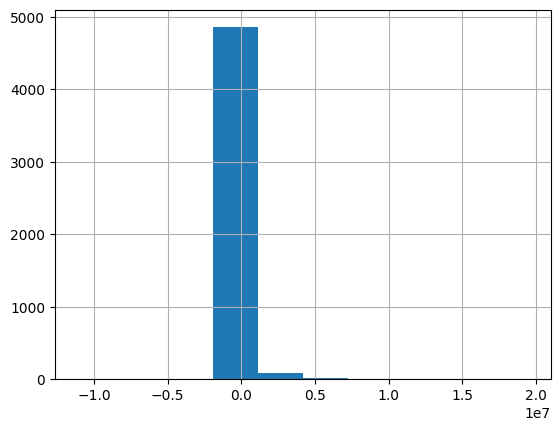

In [88]:
lm2.resid.hist()

Text(0, 0.5, 'Residuals')

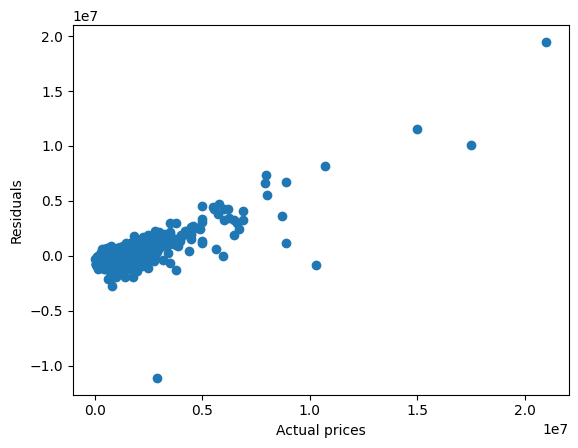

In [89]:
plt.scatter(x = train_df['listPrice'], y=lm2.resid)
plt.xlabel("Actual prices")
plt.ylabel("Residuals")

In [93]:
pred_lm2 = 5.159e+04 + test_df['type_farm']*1.412e+06 + test_df['type_multi_family']*-5.853e+05+ test_df['sqft']*365.9069 + test_df['stories']*-8.388e+04 + test_df['beds']*-9.017e+04 + test_df['baths']*1.373e+05 + test_df['baths_full']*	-8.782e+05 + test_df['baths_full_calc']*8.895e+05


In [94]:
testmse2 = mean_squared_error(test_df['listPrice'], pred_lm2)
testmse2

466939397602.3281

In [95]:
trainpred2= 5.159e+04 + train_df['type_farm']*1.412e+06 + train_df['type_multi_family']*-5.853e+05+ train_df['sqft']*365.9069 + train_df['stories']*-8.388e+04 + train_df['beds']*-9.017e+04 + train_df['baths']*1.373e+05 + train_df['baths_full']*	-8.782e+05 + train_df['baths_full_calc']*8.895e+05


In [96]:
trainmse2 = mean_squared_error(train_df['listPrice'], trainpred2)
trainmse2

371963503842.3827

In [97]:
print(testmse2 - trainmse2)

94975893759.94543


In [98]:
lm3 = smf.ols("listPrice ~ sqft + beds", data=train_df).fit()

In [99]:
lm3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              listPrice   R-squared:                       0.402
Model:                            OLS   Adj. R-squared:                  0.402
Method:                 Least Squares   F-statistic:                     1665.
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:27:21   Log-Likelihood:                -73289.
No. Observations:                4960   AIC:                         1.466e+05
Df Residuals:                    4957   BIC:                         1.466e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   7.649e+04   2.96e+04      2.587      0.010    1.85e+04    1.34e+05
sqft         404.5249      8.065     50.156      0.000     388.713     420.337
beds         -6.2e+04   1.04e+04     -5.956      0.000   -8.24e+04   -4.16e+04
==============================================================================
Omnibus:                     7828.677   Durbin-Watson:                   2.030
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         16754491.413
Skew:                           9.501   Prob(JB):                         0.00
Kurtosis:                     287.093   Cond. No.                     8.93e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.93e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

<Axes: >

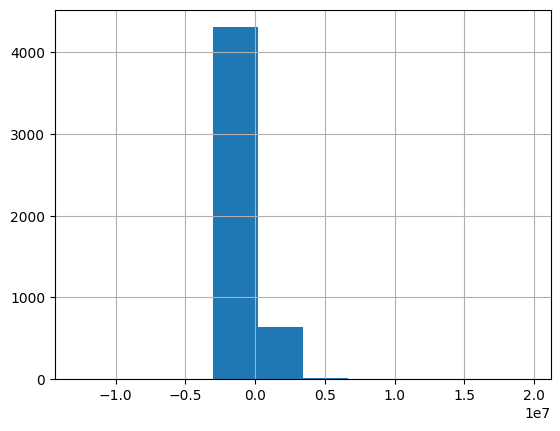

In [100]:
lm3.resid.hist()

Text(0, 0.5, 'Residuals')

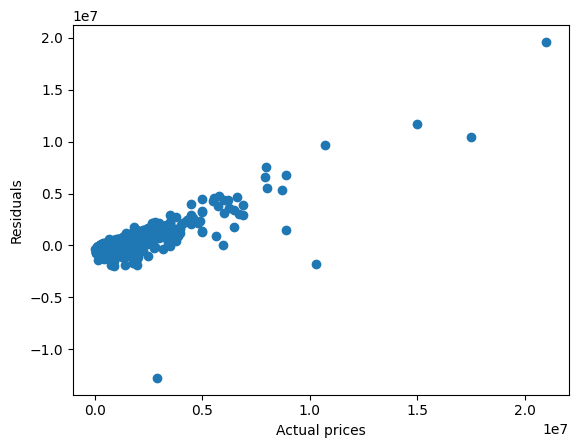

In [101]:
plt.scatter(x = train_df['listPrice'], y=lm3.resid)
plt.xlabel("Actual prices")
plt.ylabel("Residuals")

In [102]:
pred_lm3 = 		7.649e+04 + test_df['sqft']*404.5249 + test_df['beds']*-6.2e+04

In [103]:
testmse3 = mean_squared_error(test_df['listPrice'], pred_lm3)
testmse3

478533832071.28143

In [104]:
trainpred3 = 	3.137e+04 + train_df['sqft']*468.6824 + train_df['beds']*-9.074e+04

In [105]:
trainmse3 = mean_squared_error(train_df['listPrice'], trainpred3)
trainmse3

405348056706.3816

In [106]:
print(testmse3 - trainmse3)

73185775364.89984


Text(0, 0.5, 'MSE on testing - MSE on training')

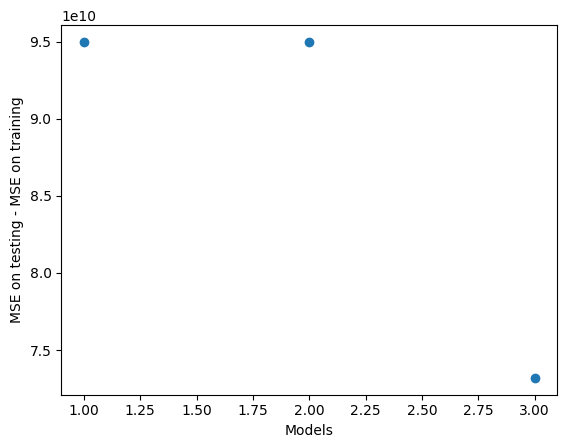

In [107]:
models = [1,2,3]
overfit = [testmse - trainmse, testmse2 - trainmse2, testmse3-trainmse3]
plt.scatter(x=models, y=overfit)
plt.xlabel("Models")
plt.ylabel("MSE on testing - MSE on training")